# 1: Import Libraries and Load Data

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset (replace with your actual file path)
data = pd.read_csv('airbnb_data.csv')

# Display the first few rows of the dataset
data.head()




,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


# 2: Data Exploration and Preprocessing

In [3]:
# Check for missing values in the dataset
print("Missing values per column:")
print(data.isnull().sum())

# Data cleaning: Handling missing values
# For numerical columns, use the median for imputation
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
imputer = SimpleImputer(strategy='median')
data[num_cols] = imputer.fit_transform(data[num_cols])

# For categorical columns, use the most frequent value for imputation
cat_cols = data.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
data[cat_cols] = imputer_cat.fit_transform(data[cat_cols])

# Merge the encoded features back to the original data
data.drop(columns=cat_cols, inplace=True)

# Feature scaling for numerical features
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# Display the cleaned and processed data
data.head()


Missing values per column:
id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     968
bedrooms                     91
beds                        131
dtype: int64


,id,log_price,accommodates,bathrooms,cleaning_fee,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
0,-0.717787,0.318608,-0.072041,-0.403569,True,0.730668,0.847996,-0.499640,0.791657,-0.311703,-0.566158
1,-0.815840,0.484855,1.785336,-0.403569,True,0.753262,0.848115,-0.393899,-0.216536,2.036637,1.029527
2,-0.550376,0.271352,0.856648,-0.403569,True,0.766896,0.850201,-0.288158,-0.360564,-0.311703,1.029527
3,0.353875,2.562075,0.392303,-0.403569,True,-0.218806,-1.383730,-0.552510,0.215547,0.862467,0.231684
4,-1.226288,-0.051767,-0.536385,-0.403569,True,0.155729,0.707800,-0.446769,-7.850000,-1.485873,-0.566158


# 3: Split Data into Training, Validation, and Test Sets

In [5]:
# Split the dataset into features (X) and target (y)
X = data.drop(columns=['log_price'])  # Assuming 'price' is the target variable
y = data['log_price']

# Split the data into training (60%), validation (20%), and testing (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Display the shapes of the resulting datasets
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 44466
Validation set size: 14822
Test set size: 14823


# 4: Model Development Using Linear Regression

In [9]:
# Create and train the Linear Regression model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred_lr = model_lr.predict(X_val)

# Make predictions on the test set
y_test_pred_lr = model_lr.predict(X_test)
# 5: Model Evaluation
# Define a function to evaluate the model using RMSE, MAE, and R²
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Evaluate the model on the validation set
rmse_val_lr, mae_val_lr, r2_val_lr = evaluate_model(y_val, y_val_pred_lr)
print(f"Validation RMSE: {rmse_val_lr:.2f}, MAE: {mae_val_lr:.2f}, R²: {r2_val_lr:.2f}")

# Evaluate the model on the test set
rmse_test_lr, mae_test_lr, r2_test_lr = evaluate_model(y_test, y_test_pred_lr)
print(f"Test RMSE: {rmse_test_lr:.2f}, MAE: {mae_test_lr:.2f}, R²: {r2_test_lr:.2f}")


Validation RMSE: 0.80, MAE: 0.62, R²: 0.36
Test RMSE: 0.80, MAE: 0.62, R²: 0.35


# 6: Visualizing the Results

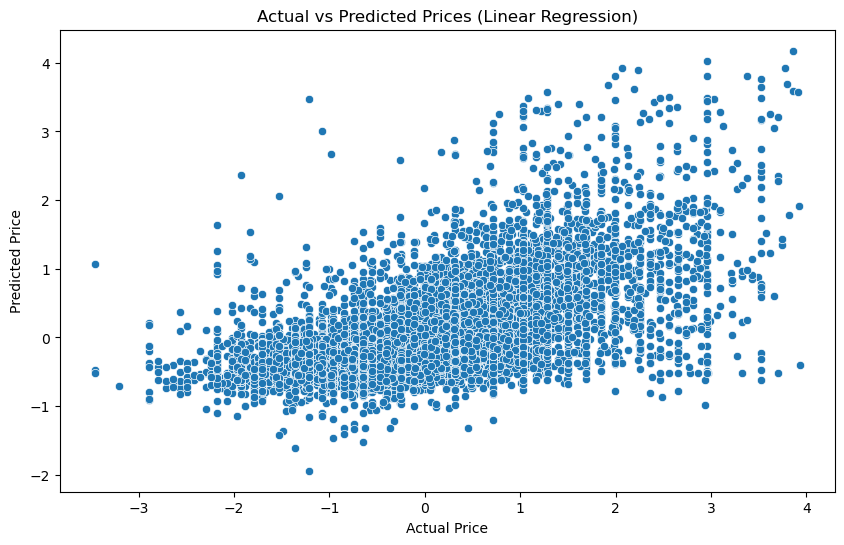

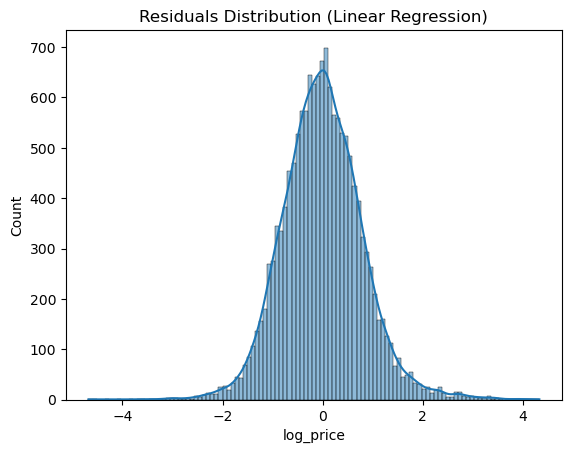

In [11]:
# Visualize the predicted vs actual values for Linear Regression on the test set
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred_lr)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Linear Regression)')
plt.show()

# Plot the residuals (difference between actual and predicted values)
residuals_lr = y_test - y_test_pred_lr
sns.histplot(residuals_lr, kde=True)
plt.title('Residuals Distribution (Linear Regression)')
plt.show()


# video Explanation


https://drive.google.com/file/d/1NtgAltpFSj7slTuPLwula5WUspRNzoIn/view?usp=sharing